# Lab 1: ACS stability.

## Task 1: The Research of stability by the Hurwitz method and the Mikhailov method (use two formulations) of a complex system with a given transfer function.

### 1.1 The Research of stability by the Hurwitz method

In [2]:
import numpy as np
import sympy as sym

# ------------------------------------------------------
# -- Functions
# ------------------------------------------------------

def hurwitz_matrix(coefs):
    N = len(coefs) - 1
    matrix = np.zeros((N, N))
    for i in range(N):
        coef_pos = 1 - i
        for j in range(N):
            if (coef_pos < 0 or coef_pos > N):
                matrix[i, j] = 0
            else:
                matrix[i, j] = coefs[coef_pos]
            coef_pos = coef_pos + 2
    return matrix

def minor(matrix, order):
    if order <= 0 or order > matrix.shape[0]:
        raise ValueError("Wrong minor order")
    return matrix[:order, :order]

def hurwitz_stability(D_p):
    is_stable = True
    a0_positive = True

    D_p_poly = sym.Poly(D_p, p)
    D_p_coeffs = D_p_poly.coeffs()

    D_p_coeffs_flipped = np.flip(D_p_coeffs)
    print(f'D_p_coeffs_flipped = {D_p_coeffs_flipped}\n')

    H = hurwitz_matrix(D_p_coeffs_flipped)

    # Calc determinators
    H_dets = np.array([])
    for i in range (1, H.shape[0] + 1):
        H_dets = np.append(H_dets, np.linalg.det(minor(H, i)))

    print(f'H_dets = {H_dets}\n')

    if D_p_coeffs[0] >= 0:
        a0_positive = True
    else:
        a0_positive = False

    for i in range(H_dets.shape[0]):
        if((H_dets[i] >= 0) != a0_positive):
            is_stable = False
    return is_stable

# ------------------------------------------------------
# -- System parameters
# ------------------------------------------------------

k = 9
T1 = 0.8
T2 = 2.6
xi = 0.09

# p = 1j*w
p = sym.Symbol('p')

# Numerator of the transfer function (not used here)
# N_p = (k*p)

# Denumerator of the transfer function
D_p = (T1*p + 1) * ((T2*p)**2 + 2*T2*xi*p + 1)


print(f'D(p) = {D_p} = {sym.expand(D_p)}\n')

if(hurwitz_stability(D_p)):
    print('The system is stable according to Hurwitz.\n')
else:
    print('The system is stable according to Hurwitz!\n')


D(p) = (0.8*p + 1)*(6.76*p**2 + 0.468*p + 1) = 5.408*p**3 + 7.1344*p**2 + 1.268*p + 1

D_p_coeffs_flipped = [1.00000000000000 1.26800000000000 7.13440000000000 5.40800000000000]

H_dets = [ 1.268       3.6384192  19.67657103]

The system is stable according to Hurwitz.



### 1.2 The Research of stability by the Mikhailov method

System order = 3
roots = [-1.25      +0.j         -0.03461538+0.38305453j -0.03461538-0.38305453j]


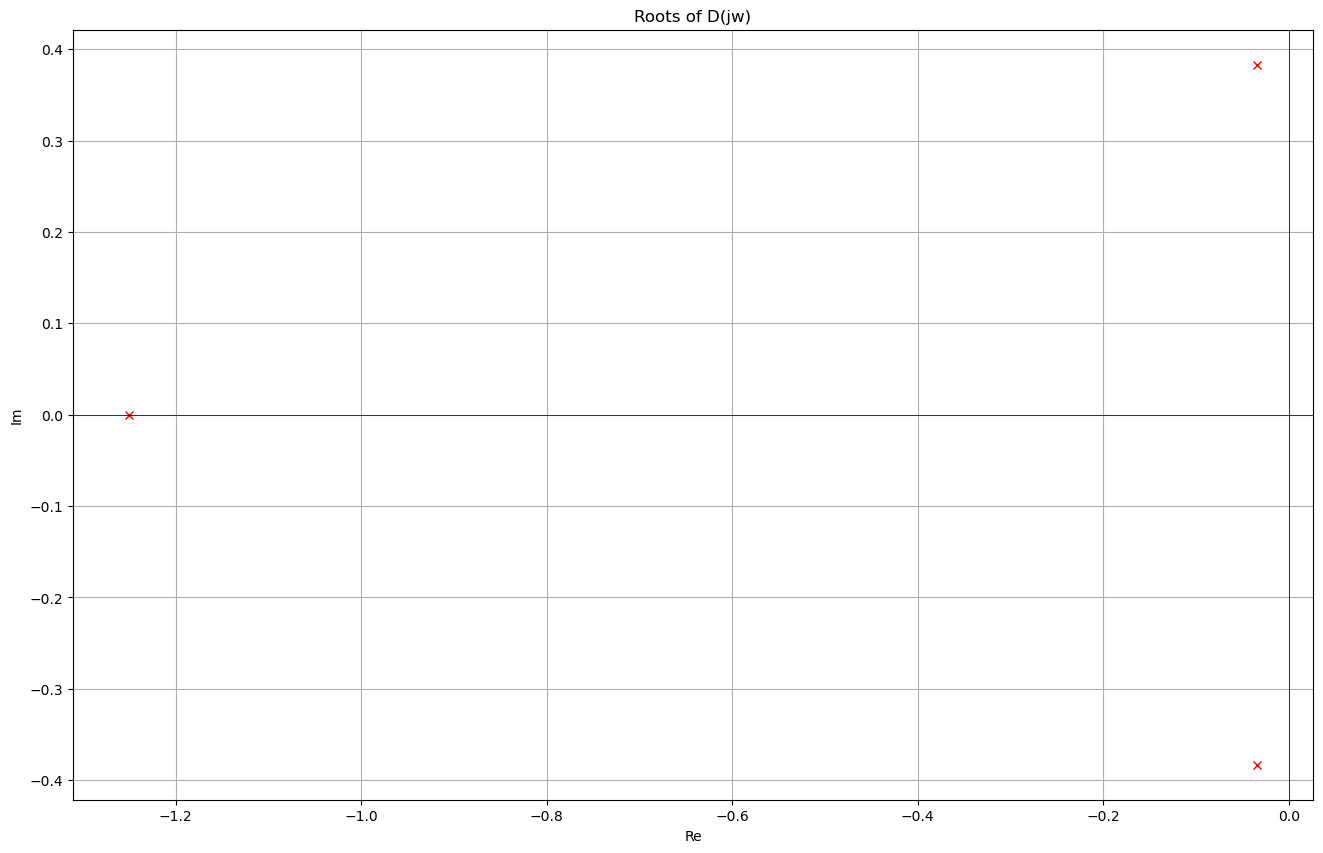

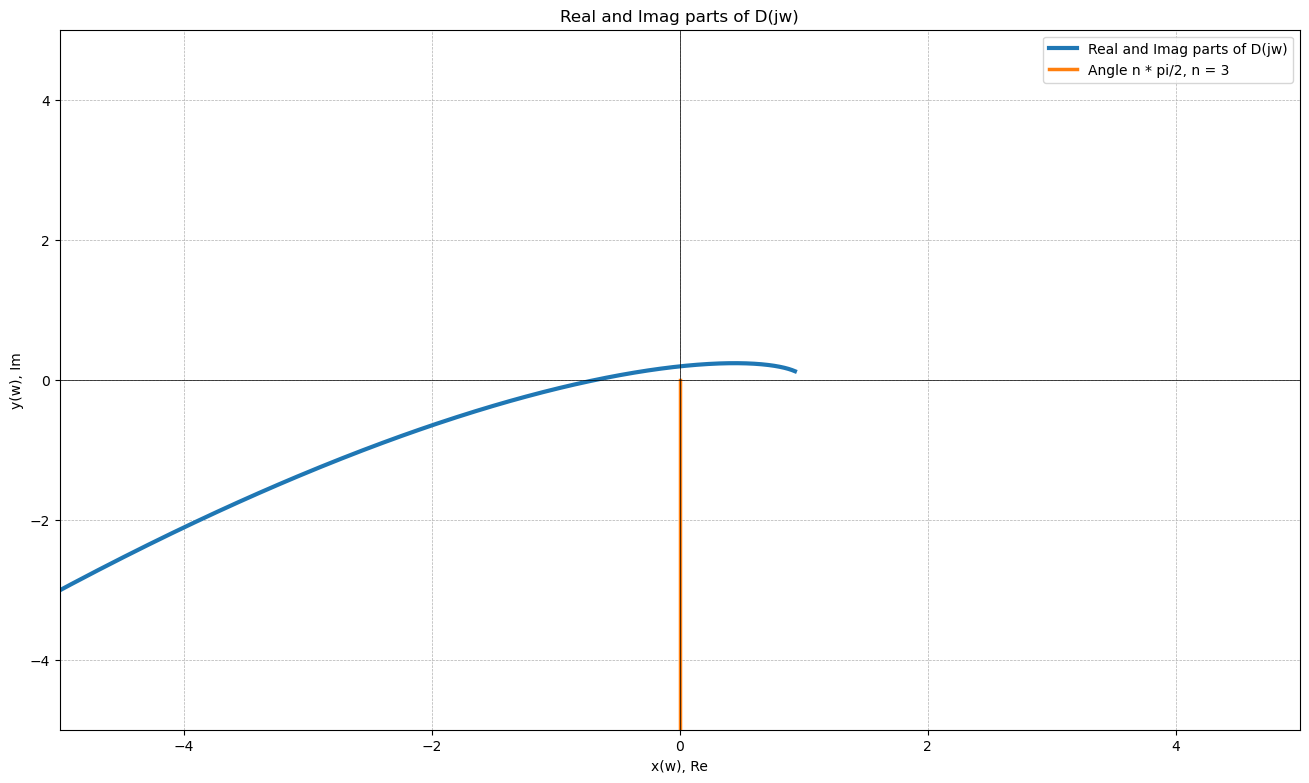

In [30]:
import numpy as np
import sympy as sym
import matplotlib.pyplot as plt
# from scipy import signal

# ------------------------------------------------------
# -- Mikhailov method
# ------------------------------------------------------

# ------------------------------------------------------
# -- System parameters
# ------------------------------------------------------

k = 9
T1 = 0.8
T2 = 2.6
xi = 0.09

only_left_roots = True
is_stable = True

w = np.logspace(-1, 1, 10**3)

p_sym = sym.Symbol('p')
p = 1j * w

# Denumerator of the transfer function
D_p_sym = (T1*p_sym + 1) * ((T2*p_sym)**2 + 2*T2*xi*p_sym + 1)
D_p = (T1*p + 1) * ((T2*p)**2 + 2*T2*xi*p + 1)

x_w = np.real(D_p)
y_w = np.imag(D_p)

n = len(((sym.Poly(D_p_sym)).coeffs())) - 1
print(f'System order = {n}')

angle_radians = n * np.pi / 2

# Numerator
num = [k]

# Denumerator
den = np.convolve([T1, 1], [T2**2, 2*T2*xi, 1])

# Transfer function
tr_func = signal.TransferFunction(num, den)

# Get roots of Mikhailov function
roots = tr_func.poles
print(f'roots = {roots}')

for i in range (len(roots)):
    if(roots[i].real >= 0.0):
        only_left_roots = False
        break

# w, mag, phase = signal.bode(tr_func, w)

plt.figure(figsize=(16, 10))
plt.subplot(1, 1, 1)
plt.plot(roots.real, roots.imag, 'x', color='red', linewidth='3')
plt.axvline(0, color='k', linewidth=0.5)
plt.axhline(0, color='k', linewidth=0.5)
plt.title('Roots of D(jw)')
plt.xlabel('Re')
plt.ylabel('Im')
plt.grid()
plt.show()


plt.figure(figsize=(16, 20))
# plt.subplot(2, 1, 1, polar=True)
# plt.grid(True, which="both", linestyle="--", linewidth=0.5)
# plt.polar(phase, mag, label='D(jw)')
# plt.polar(np.pi * system_order / 2, 10, label=f'PI/2 * {system_order}', linewidth='3.0')
# plt.title("Mihkailov function D(jw)")
# # plt.xlabel("Magnitude")
# # plt.ylabel("Phase")
# plt.legend()

m = np.tan(angle_radians)
angle_x = np.linspace(-5, 0, 100)
angle_y = angle_x * m
plt.subplot(2, 1, 1, polar=False)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.plot(x_w, y_w, linewidth='3', label='Real and Imag parts of D(jw)')
plt.plot(angle_x, angle_y, linewidth='2.5', label=f'Angle n * pi/2, n = {n}')
plt.axvline(0, color='k', linewidth=0.5)
plt.axhline(0, color='k', linewidth=0.5)
plt.title("Real and Imag parts of D(jw)")
plt.xlabel("x(w), Re")
plt.ylabel("y(w), Im")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.legend()

plt.show()

# if(not only_left_roots or ):